# **ANÁLISE DE DADOS DE SAÚDE DO APPLE WATCH: CLASSIFICAÇÃO DA FREQUÊNCIA CARDÍACA**


## **1. Decrição**

<blockquote>

O trabalho consiste na classificação de séries temporais de frequência cardíaca utilizando Machine Learning.

Os dados foram obtidos de um Apple Watch pertencente à minha irmã, Karine. As classes foram definidas de acordo com a frequência cardíaca:

**Normal:** 70 a 100 bpm;

**Atenção:** 64–70 ou 100–120 bpm;

**Alerta:** abaixo de 64 ou acima de 120 bpm.

Foi utilizado o Random Forest para criar o modelo de classificação, tendo o 1-NN com DTW como método de comparação (baseline). O objetivo é identificar automaticamente a classe de cada janela da série temporal.

</blockquote>


## **2. Coleta e Importação dos dados**

<blockquote>......</blockquote>

In [71]:
# Importação das bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [72]:
# Importação dos dados de frequência cardíaca da minha irma Karine
df_heart_rate = pd.read_excel('healthsave-heart-rate-karine.xlsx')
df_heart_rate.head()

,startDate,endDate,value,unit,source
0,2026-01-02 09:10:10,2026-01-02 09:10:10,80,count/min,AppleÂ Watch de Karine
1,2026-01-02 09:14:56,2026-01-02 09:14:56,77,count/min,AppleÂ Watch de Karine
2,2026-01-02 09:16:25,2026-01-02 09:16:25,76,count/min,AppleÂ Watch de Karine
3,2026-01-02 09:17:29,2026-01-02 09:17:29,78,count/min,AppleÂ Watch de Karine
4,2026-01-02 09:23:02,2026-01-02 09:23:02,72,count/min,AppleÂ Watch de Karine


## **3. Exploração dos dados**

<blockquote>......</blockquote>

In [73]:
df_heart_rate.shape

(17985, 5)

In [74]:

print("Número de observações:", len(df_heart_rate))
print("Primeira data:", df_heart_rate["startDate"].min())
print("Última data:", df_heart_rate["startDate"].max())


Número de observações: 17985
Primeira data: 2026-01-02 09:10:10
Última data: 2026-08-27 08:57:20


In [75]:
df_heart_rate["value"].describe()

,value
count,17985.000000
mean,79.175146
std,16.511717
min,40.000000
25%,70.000000
50%,77.000000
75%,85.000000
max,200.000000


## **4. Limpeza e Transformação dos dados**

<blockquote>......</blockquote>

In [76]:

# Requisito da atividade
TAMANHO_JANELA = 30

# Requisitos mínimos de treinamento e teste
MIN_TREINO = 30
MIN_TESTE = 30
MIN_POR_CLASSE_TREINO = 10

CLASSES = ["Normal", "Atenção", "Alerta"]

In [77]:
# Conversão do tipo de dados de algumas colunas
df_heart_rate["startDate"]  = pd.to_datetime(df_heart_rate["startDate"])
df_heart_rate['month']      = df_heart_rate['startDate'].dt.month
df_heart_rate['value']      = pd.to_numeric(df_heart_rate["value"],errors="coerce")

In [78]:
df_heart_rate.head()

,startDate,endDate,value,unit,source,month
0,2026-01-02 09:10:10,2026-01-02 09:10:10,80,count/min,AppleÂ Watch de Karine,1
1,2026-01-02 09:14:56,2026-01-02 09:14:56,77,count/min,AppleÂ Watch de Karine,1
2,2026-01-02 09:16:25,2026-01-02 09:16:25,76,count/min,AppleÂ Watch de Karine,1
3,2026-01-02 09:17:29,2026-01-02 09:17:29,78,count/min,AppleÂ Watch de Karine,1
4,2026-01-02 09:23:02,2026-01-02 09:23:02,72,count/min,AppleÂ Watch de Karine,1


In [79]:
# Remove valores ausentes e duplicidades
# e coloca os dados em ordem cronológica
df_heart_rate = (
    df_heart_rate.dropna()
      .drop_duplicates(subset=["startDate"])
      .sort_values("startDate")
      .reset_index(drop=True)
)

In [103]:
df_heart_rate["value"].describe()

,value
count,17956.000000
mean,79.183783
std,16.519028
min,40.000000
25%,70.000000
50%,77.000000
75%,85.000000
max,200.000000


In [80]:
# CRIAÇÃO DOS RÓTULOS

def rotular(valor):

    if 70 <= valor <= 100:
        return "Normal"
    elif (64 <= valor < 70) or (100 < valor <= 120):
        return "Atenção"
    else:
        return "Alerta"

# Cria um rótulo para cada observação individual
df_heart_rate["label_ponto"] = df_heart_rate["value"].apply(rotular)

print("\nDistribuição dos pontos:")
print(
    df_heart_rate["label_ponto"]
    .value_counts()
    .reindex(CLASSES, fill_value=0)
)


Distribuição dos pontos:
label_ponto
Normal     12657
Atenção     3060
Alerta      2239
Name: count, dtype: int64


In [81]:
# SEGMENTAÇÃO EM JANELAS DE 30 OBSERVAÇÕES

"""
Cada exemplo será uma série temporal univariada contendo
exatamente 30 observações de frequência cardíaca.
Exemplo:

Exemplo 1 = [x1, x2, ..., x30]
Exemplo 2 = [x31, x32, ..., x60]
Exemplo 3 = [x61, x62, ..., x90]

"""

valores = df_heart_rate["value"].to_numpy(dtype=float)

X = []
y = []

for inicio in range(
    0,
    len(valores) - TAMANHO_JANELA + 1,
    TAMANHO_JANELA
):

    # Extrai 30 observações
    janela = valores[
        inicio:inicio + TAMANHO_JANELA
    ]

    # A classe da janela é determinada pela média
    # das 30 observações
    media_janela = janela.mean()

    classe = rotular(media_janela)

    X.append(janela)
    y.append(classe)


X = np.asarray(X)
y = np.asarray(y)

print("Tamanho da janela:", TAMANHO_JANELA)
print("Número total de exemplos:", len(X))

print("\nDistribuição das classes:")
print(
    pd.Series(y)
    .value_counts()
    .reindex(CLASSES, fill_value=0)
)

Tamanho da janela: 30
Número total de exemplos: 598

Distribuição das classes:
Normal     540
Atenção     47
Alerta      11
Name: count, dtype: int64


## **5. Análises e Visualizações**

<blockquote>......</blockquote>

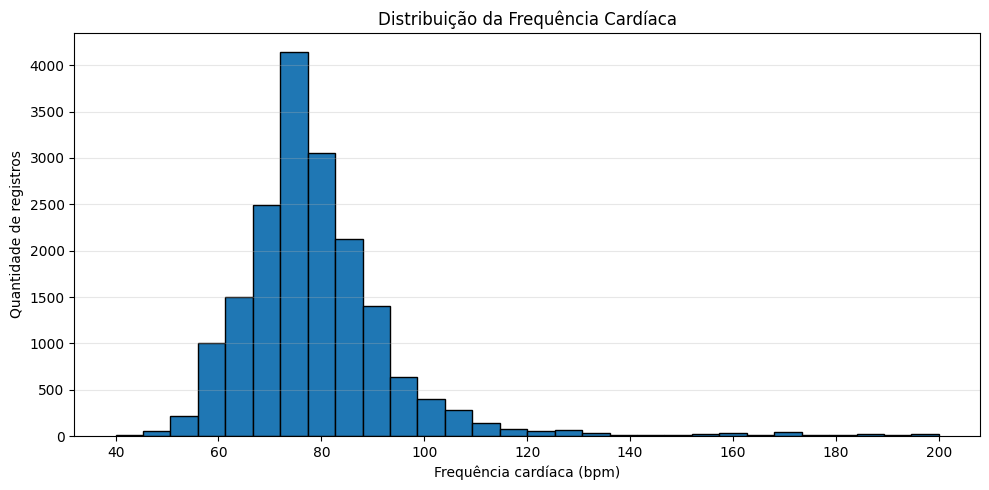

In [82]:

plt.figure(figsize=(10, 5))
plt.hist(df_heart_rate["value"], bins=30, edgecolor="black")
plt.title("Distribuição da Frequência Cardíaca")
plt.xlabel("Frequência cardíaca (bpm)")
plt.ylabel("Quantidade de registros")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

O histograma mostra que a maior parte dos registros de frequência cardíaca está concentrada entre aproximadamente 65 e 90 bpm, com maior frequência na faixa de 75 a 80 bpm. A distribuição apresenta assimetria à direita devido à presença de poucos valores elevados, que chegam a aproximadamente 200 bpm. Observa-se também uma quantidade reduzida de registros acima de 120 bpm e abaixo de 60 bpm. Esses valores menos frequentes são importantes para a classificação, pois podem contribuir para a identificação das classes Atenção e Alerta.

 **OBS:** *Como os dados vêm de um Apple Watch, podem existir situações de leitura atípica causadas por movimento, contato inadequado do sensor ou outras condições de medição.*

Dias com média diária acima de 90 bpm:
          data       value
19  2026-01-27   94.055276
39  2026-02-20   97.183333
50  2026-03-07   97.503937
81  2026-04-16   97.308176
83  2026-04-18   97.489796
91  2026-05-01   90.823944
98  2026-05-09  110.720779
116 2026-05-30  107.844444
149 2026-07-10   90.978723


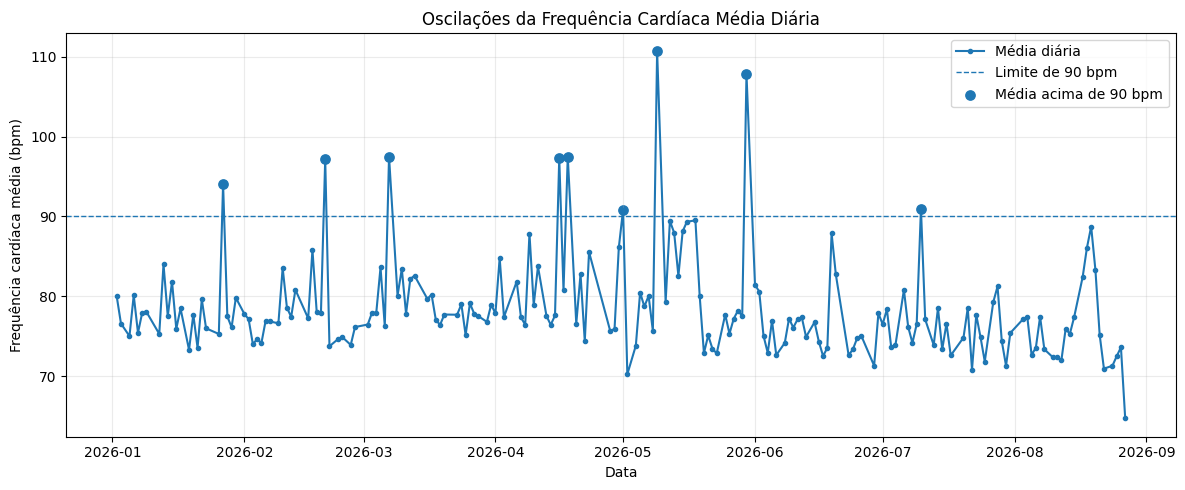

In [102]:

df = df_heart_rate.copy()

# Conversão dos tipos de dados
df["startDate"] = pd.to_datetime(
    df["startDate"],
    errors="coerce"
)

df["value"] = pd.to_numeric(
    df["value"],
    errors="coerce"
)

# Remoção de valores ausentes
df = df.dropna(
    subset=["startDate", "value"]
)

# Ordenação cronológica e remoção de duplicatas
df = (
    df.sort_values("startDate")
      .drop_duplicates("startDate")
)

# CÁLCULO DA MÉDIA DIÁRIA
# Criação da coluna contendo apenas a data
df["data"] = df["startDate"].dt.date

# Cálculo da média diária
media_diaria = (
    df.groupby("data")["value"]
      .mean()
      .reset_index()
)

# Conversão da coluna para formato de data
media_diaria["data"] = pd.to_datetime(
    media_diaria["data"]
)

# IDENTIFICAÇÃO DAS OSCILAÇÕES
# Seleciona os dias cuja média ultrapassou 90 bpm
oscilacoes = media_diaria[
    media_diaria["value"] > 90
]

# Exibe os dias identificados
print("Dias com média diária acima de 90 bpm:")
print(oscilacoes)

# GERAÇÃO DO GRÁFICO

plt.figure(figsize=(12, 5))

# Linha com as médias diárias
plt.plot(
    media_diaria["data"],
    media_diaria["value"],
    marker="o",
    markersize=3,
    linewidth=1.5,
    label="Média diária"
)

# Linha de referência em 90 bpm
plt.axhline(
    y=90,
    linestyle="--",
    linewidth=1,
    label="Limite de 90 bpm"
)

# Destaque dos dias acima de 90 bpm
plt.scatter(
    oscilacoes["data"],
    oscilacoes["value"],
    s=45,
    label="Média acima de 90 bpm"
)

# Título e rótulos
plt.title(
    "Oscilações da Frequência Cardíaca Média Diária"
)

plt.xlabel("Data")
plt.ylabel("Frequência cardíaca média (bpm)")

# Grade e legenda
plt.grid(
    True,
    alpha=0.25
)

plt.legend()
plt.tight_layout()
plt.show()

O gráfico mostra que a frequência cardíaca média diária permaneceu relativamente estável, principalmente entre 70 e 85 bpm, durante o período analisado. Foram observadas algumas oscilações pontuais acima de 90 bpm, com maior destaque para o mês de Maio, quando ocorreram os maiores picos, chegando a aproximadamente 111 bpm de média diária.

De modo geral, os valores elevados foram pontuais, não indicando uma tendência contínua de aumento da frequência cardíaca ao longo do período.

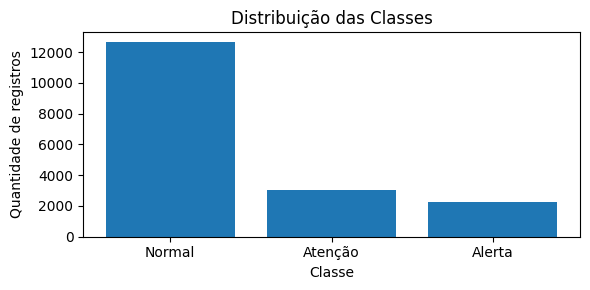

In [84]:
ordem = ["Normal", "Atenção", "Alerta"]

contagem = df_heart_rate["label_ponto"].value_counts().reindex(ordem)
plt.figure(figsize=(6, 3))
plt.bar(contagem.index, contagem.values)
plt.title("Distribuição das Classes")
plt.xlabel("Classe")
plt.ylabel("Quantidade de registros")
plt.tight_layout()
plt.show()

O gráfico apresenta a distribuição dos registros entre as classes Normal, Atenção e Alerta. Observa-se uma predominância da classe Normal. Essa distribuição evidencia um desequilíbrio entre as classes, que deve ser considerado na avaliação dos modelos.

/tmp/ipykernel_7372/1179706995.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(dados_boxplot,labels=classes);


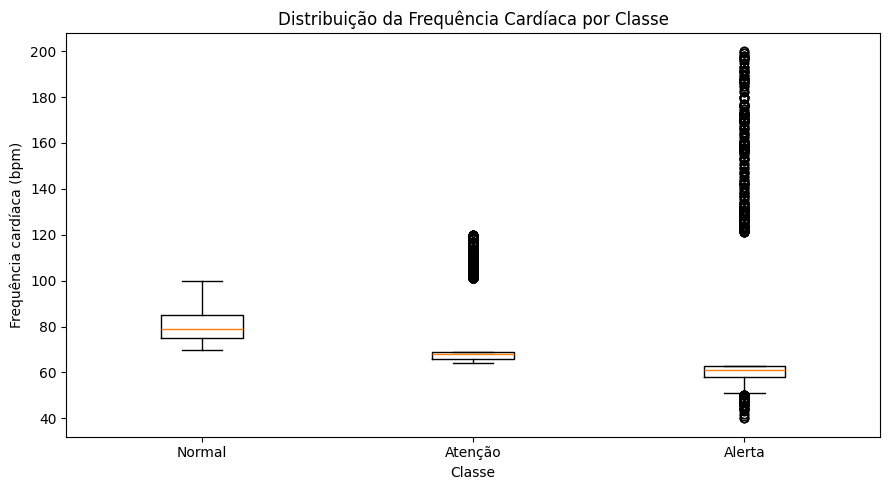

In [85]:
# Boxplot por classe
# Esse gráfico mostra visualmente que as classes foram criadas a partir de diferentes
# faixas de frequência cardíaca.
classes = ["Normal", "Atenção", "Alerta"]

dados_boxplot = [
    df_heart_rate[df_heart_rate["label_ponto"] == classe]["value"]
    for classe in classes
]

plt.figure(figsize=(9, 5))
plt.boxplot(dados_boxplot,labels=classes);
plt.title("Distribuição da Frequência Cardíaca por Classe")
plt.xlabel("Classe")
plt.ylabel("Frequência cardíaca (bpm)")
plt.tight_layout()
plt.show()

O boxplot apresenta a distribuição da frequência cardíaca em cada classe. A classe Normal concentra-se principalmente entre 70 e 85 bpm, enquanto a classe Atenção apresenta valores predominantemente entre 64 e 70 bpm. A classe Alerta possui mediana próxima de 60 bpm e apresenta maior quantidade de valores extremos, incluindo registros abaixo de 50 bpm e acima de 120 bpm. Dessa forma, observa-se uma diferenciação relevante entre as classes.

## **6. Modelagem / Machine Learning**

<blockquote>......</blockquote>

In [88]:
# DIVISÃO CRONOLÓGICA TREINO / TESTE

# Mantém a ordem temporal dos dados.
# Os primeiros 70% das janelas são usados para treinamento
# e os últimos 30% para teste.

corte = int(len(X) * 0.70)

# Divisão definitiva
X_train = X[:corte]
X_test = X[corte:]

y_train = y[:corte]
y_test = y[corte:]

# Exibe o tamanho dos conjuntos
print(f"Total de janelas: {len(X)}")
print(f"Janelas de treino: {len(X_train)}")
print(f"Janelas de teste: {len(X_test)}")

# Exibe a distribuição das classes
print("\nDistribuição das classes no treino:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nDistribuição das classes no teste:")
print(pd.Series(y_test).value_counts().sort_index())

Total de janelas: 598
Janelas de treino: 418
Janelas de teste: 180

Distribuição das classes no treino:
Alerta       4
Atenção     31
Normal     383
Name: count, dtype: int64

Distribuição das classes no teste:
Alerta       7
Atenção     16
Normal     157
Name: count, dtype: int64


In [89]:
# NORMALIZAÇÃO

# O StandardScaler faz a padronização usando a média e o desvio padrão dos dados.
# Calcula a média e o desvio padrão de cada variável somente no treino
# scaler.fit_transform(X_train)
# No teste: scaler.transform(X_test)

scaler = StandardScaler()

scaler.fit(
    X_train.reshape(-1, 1)
)

X_train_norm = scaler.transform(
    X_train.reshape(-1, 1)
).reshape(X_train.shape)

X_test_norm = scaler.transform(
    X_test.reshape(-1, 1)
).reshape(X_test.shape)


In [90]:
# EXTRAÇÃO DE CARACTERÍSTICAS

def extrair_features(X):

    features = []
    for janela in X:

        tempo = np.arange(len(janela))

        media = np.mean(janela)
        desvio = np.std(janela)
        minimo = np.min(janela)
        maximo = np.max(janela)
        mediana = np.median(janela)

        q25 = np.percentile(janela,25)
        q75 = np.percentile(janela,75)

        # Variação média entre pontos consecutivos
        variacao = np.mean(
            np.abs(np.diff(janela))
        )

        # Inclinação aproximada da série
        inclinacao = np.polyfit(
            tempo,
            janela,
            1
        )[0]

        features.append([
            media,
            desvio,
            minimo,
            maximo,
            mediana,
            q25,
            q75,
            variacao,
            inclinacao
        ])

    return np.asarray(features)

F_train = extrair_features(X_train_norm)
F_test = extrair_features(X_test_norm)

In [91]:
# CLASSIFICADOR RANDOM FOREST

modelo = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    min_samples_leaf=2
)

# Treinamento
modelo.fit(F_train,y_train)

# Previsão
pred_rf = modelo.predict(F_test)

# Acurácia
acc_rf = accuracy_score(y_test,pred_rf)

print(
    "Acurácia:",
    round(acc_rf, 4)
)

print("\nRelatório de classificação:")
print(
    classification_report(
        y_test,
        pred_rf,
        labels=CLASSES,
        zero_division=0
    )
)

Acurácia: 0.9667

Relatório de classificação:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       157
     Atenção       0.73      1.00      0.84        16
      Alerta       1.00      0.14      0.25         7

    accuracy                           0.97       180
   macro avg       0.91      0.71      0.70       180
weighted avg       0.98      0.97      0.96       180



In [92]:
# BASELINE: 1-NN + DTW

"""
Dynamic Time Warping permite comparar duas séries temporais
mesmo quando pequenas variações acontecem no alinhamento temporal.
"""

def dtw_distance(a, b):

    n = len(a)
    m = len(b)

    # Matriz de programação dinâmica
    D = np.full(
        (n + 1, m + 1),
        np.inf
    )

    D[0, 0] = 0

    for i in range(1, n + 1):

        for j in range(1, m + 1):

            custo = abs(
                a[i - 1] -
                b[j - 1]
            )

            D[i, j] = custo + min(
                D[i - 1, j],
                D[i, j - 1],
                D[i - 1, j - 1]
            )

    return D[n, m]


def knn_dtw(
    X_train,
    y_train,
    X_test
):
    """
    Classificador 1-NN DTW.

    Para cada exemplo de teste:

    1. Calcula DTW contra todos os exemplos de treino.
    2. Encontra a menor distância.
    3. Copia o rótulo do vizinho mais próximo.
    """

    previsoes = []

    for teste in X_test:

        menor_distancia = np.inf

        classe = None

        for i, treino in enumerate(
            X_train
        ):

            distancia = dtw_distance(
                teste,
                treino
            )

            if distancia < menor_distancia:

                menor_distancia = distancia

                classe = y_train[i]

        previsoes.append(
            classe
        )

    return np.asarray(
        previsoes
    )

pred_dtw = knn_dtw(
    X_train_norm,
    y_train,
    X_test_norm
)

acc_dtw = accuracy_score(
    y_test,
    pred_dtw
)

print("Acurácia:",round(acc_dtw, 4))
print("\nRelatório de classificação:")
print(
    classification_report(
        y_test,
        pred_dtw,
        labels=CLASSES,
        zero_division=0
    )
)

Acurácia: 0.8889

Relatório de classificação:
              precision    recall  f1-score   support

      Normal       0.95      0.97      0.96       157
     Atenção       0.40      0.50      0.44        16
      Alerta       0.00      0.00      0.00         7

    accuracy                           0.89       180
   macro avg       0.45      0.49      0.47       180
weighted avg       0.86      0.89      0.88       180



## **7. Avaliação do Modelo**

<blockquote>......</blockquote>

In [93]:
# MATRIZES DE CONFUSÃO

cm_rf = confusion_matrix(
    y_test,
    pred_rf,
    labels=CLASSES
)

cm_dtw = confusion_matrix(
    y_test,
    pred_dtw,
    labels=CLASSES
)

print("MATRIZ DE CONFUSÃO - RANDOM FOREST")
print(
    pd.DataFrame(
        cm_rf,
        index=[
            "Real Normal",
            "Real Atenção",
            "Real Alerta"
        ],
        columns=[
            "Pred. Normal",
            "Pred. Atenção",
            "Pred. Alerta"
        ]
    )
)


print("MATRIZ DE CONFUSÃO - 1-NN DTW")
print(
    pd.DataFrame(
        cm_dtw,
        index=[
            "Real Normal",
            "Real Atenção",
            "Real Alerta"
        ],
        columns=[
            "Pred. Normal",
            "Pred. Atenção",
            "Pred. Alerta"
        ]
    )
)


MATRIZ DE CONFUSÃO - RANDOM FOREST
              Pred. Normal  Pred. Atenção  Pred. Alerta
Real Normal            157              0             0
Real Atenção             0             16             0
Real Alerta              0              6             1
MATRIZ DE CONFUSÃO - 1-NN DTW
              Pred. Normal  Pred. Atenção  Pred. Alerta
Real Normal            152              5             0
Real Atenção             8              8             0
Real Alerta              0              7             0


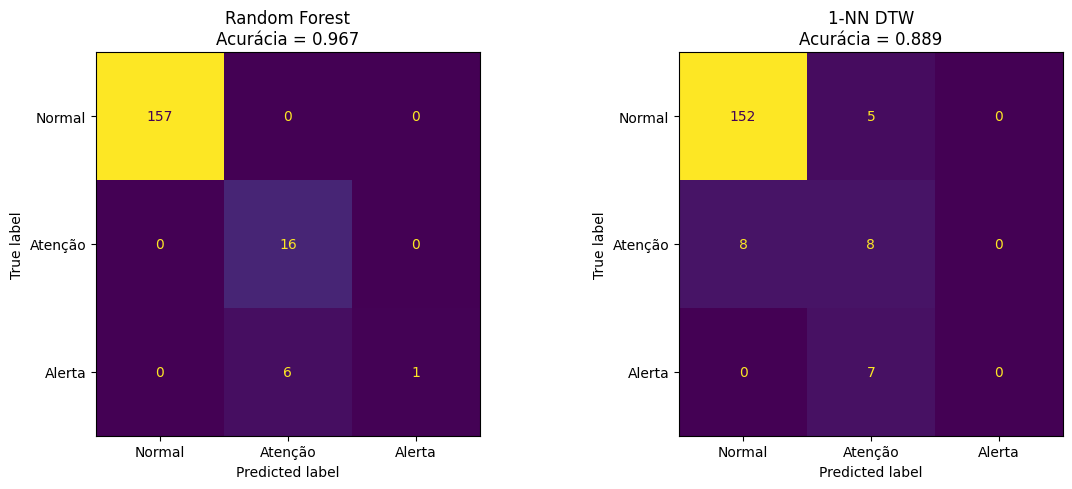

In [94]:
# VISUALIZAÇÃO DAS MATRIZES

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

ConfusionMatrixDisplay(
    cm_rf,
    display_labels=CLASSES
).plot(
    ax=axes[0],
    values_format="d",
    colorbar=False
)

axes[0].set_title(
    f"Random Forest\n"
    f"Acurácia = {acc_rf:.3f}"
)

ConfusionMatrixDisplay(
    cm_dtw,
    display_labels=CLASSES
).plot(
    ax=axes[1],
    values_format="d",
    colorbar=False
)

axes[1].set_title(
    f"1-NN DTW\n"
    f"Acurácia = {acc_dtw:.3f}"
)

plt.tight_layout()
plt.show()

In [95]:
# COMPARAÇÃO FINAL

resultado = pd.DataFrame({

    "Modelo": [
        "Random Forest",
        "1-NN DTW"
    ],

    "Acurácia": [
        acc_rf,
        acc_dtw
    ]
})

print(resultado.to_string(index=False))
print("\nConfiguração:")
print(f"- Tamanho da janela: {TAMANHO_JANELA}")
print(f"- Exemplos de treino: {len(X_train)}")
print(f"- Exemplos de teste: {len(X_test)}")
print("- Mínimo por classe no treino: 10")
print("- Divisão: cronológica")


       Modelo  Acurácia
Random Forest  0.966667
     1-NN DTW  0.888889

Configuração:
- Tamanho da janela: 30
- Exemplos de treino: 418
- Exemplos de teste: 180
- Mínimo por classe no treino: 10
- Divisão: cronológica


O Random Forest apresentou maior acurácia (96,7%) em comparação ao 1-NN DTW (88,9%). Além disso, o Random Forest identificou corretamente todos os exemplos de Normal e Atenção, enquanto o DTW apresentou erros nessas duas classes.

A principal limitação observada nos dois métodos está na classe Alerta. O Random Forest identificou apenas 1 dos 7 exemplos, enquanto o 1-NN DTW não identificou nenhum.
Isso indica que, apesar da alta acurácia geral do Random Forest, a classe Alerta ainda apresenta dificuldade de classificação, possivelmente relacionada à quantidade reduzida de exemplos disponíveis.

## **8. Conclusão e Próximos Passos**

<blockquote>

O projeto demonstrou a aplicação de técnicas de aprendizado de máquina na classificação de dados de frequência cardíaca em três classes: **Normal, Atenção e Alerta**. O modelo **Random Forest apresentou acurácia de 96,6%**, superior ao baseline **1-NN com DTW, que apresentou 88,8%**.

As matrizes de confusão mostram que o Random Forest teve melhor desempenho geral, porém ambos os métodos apresentaram dificuldade principalmente na identificação da classe Alerta. Esse resultado deve ser interpretado considerando a menor quantidade de exemplos dessa classe no conjunto de teste.

A análise exploratória mostrou que a frequência cardíaca média diária permaneceu relativamente estável, principalmente entre 70 e 85 bpm, durante o período analisado. Foram observadas algumas oscilações pontuais acima de 90 bpm, com maior destaque para maio, quando ocorreram os maiores picos, chegando a aproximadamente 111 bpm de média diária.
De modo geral, os valores elevados foram pontuais, não indicando uma tendência contínua de aumento da frequência cardíaca ao longo do período.


**Próximos Passos**

Como melhorias futuras, pretende-se:

* Utilizar **validação temporal progressiva (walk-forward)** para avaliar o comportamento do modelo em diferentes períodos;
* Testar diferentes **tamanhos de janela** para identificar qual representa melhor os padrões da frequência cardíaca;
* Investigar técnicas para lidar melhor com o **desbalanceamento das classes**;
* Testar outros algoritmos de classificação e comparar seus resultados;
* Utilizar dados de **mais pessoas e diferentes dispositivos**, aumentando a capacidade de generalização;

Dessa forma, o projeto atual representa uma primeira etapa na aplicação de técnicas de Machine Learning à classificação de séries temporais de frequência cardíaca, servindo como base para avaliações mais robustas e para o desenvolvimento de modelos com maior capacidade de generalização.

</blockquote>